<a href="https://colab.research.google.com/github/PavaniReddy911/RNN/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense

In [ ]:
#Input Sentence
sentence = ["I","Love","Deep","Learning"]
print(sentence)


['I', 'Love', 'Deep', 'Learning']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#Word Embeddings
word_embeddings = {"I":1.0,
                   "Love":2.0,
                   "Deep":3.0,
                   "Learning":4.0}
print(word_embeddings)

{'I': 1.0, 'Love': 2.0, 'Deep': 3.0, 'Learning': 4.0}


In [ ]:
#Prepeare Sequencw Data
X=np.array([
    [word_embeddings["I"],word_embeddings["Love"],word_embeddings["Deep"]],
    [word_embeddings["I"],word_embeddings["Love"],word_embeddings["Learning"]]
])
print(X)

[[1. 2. 3.]
 [1. 2. 4.]]


In [ ]:
import numpy as np
#Word Embeddings (duplicated for execution consistency)
word_embeddings = {"I":1.0,
                   "Love":2.0,
                   "Deep":3.0,
                   "Learning":4.0}
y = np.array([word_embeddings["Learning"], word_embeddings["Learning"]])
X = X.reshape(X.shape[0], X.shape[1], 1)
print(y)
print("Input Shape:", X.shape)
print("Output shape:", y.shape)

[4. 4.]
Input Shape: (2, 3, 1)
Output shape: (2,)


In [ ]:
#Build Simple RNN Model
model=Sequential()
model.add(SimpleRNN(units=8,
                    activation='tanh',input_shape=(3,1)))
model.add(Dense(units=1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
#Train the Model
model.fit(X,y,epochs=300,verbose=1)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 16.8014
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 16.6543
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 16.5080
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 16.3627
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 16.2184
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 16.0750
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 15.9326
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 15.7913
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 15.6510
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 15.5117
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 15.3736
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 15.2365
Epoch 13/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 15.1006
Epoch 14/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 14.9658
Epoch 15/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 14.8321
Epoch

In [ ]:
#Prediction
test_sequence=np.array([
    [
    [1.0],[2.0],[3.0]
    ]
    ])
prediction=model.predict(test_sequence)
print("Prediction:",prediction[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
Prediction: 3.432675


In [ ]:
#Convert Prediction to Closest Word
predicted_number=prediction[0][0]
closest_word=min(word_embeddings,key=lambda word:abs(word_embeddings[word]-predicted_number))
print("Predicted Word:",closest_word)

Predicted Word: Deep


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

100%|██████████| 11.1M/11.1M [00:00<00:00, 247MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/versions/1


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-for-mental-health


#Task 1 — Dataset Understanding
Analyze:
number of sentiment classes
text distribution
class imbalance
average sentence length

Contents of /kaggle/input/sentiment-analysis-for-mental-health: ['Combined Data.csv']
   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety

Dataset Shape:
(53043, 3)

Unique Sentiment Classes:
['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']

Class Distribution:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


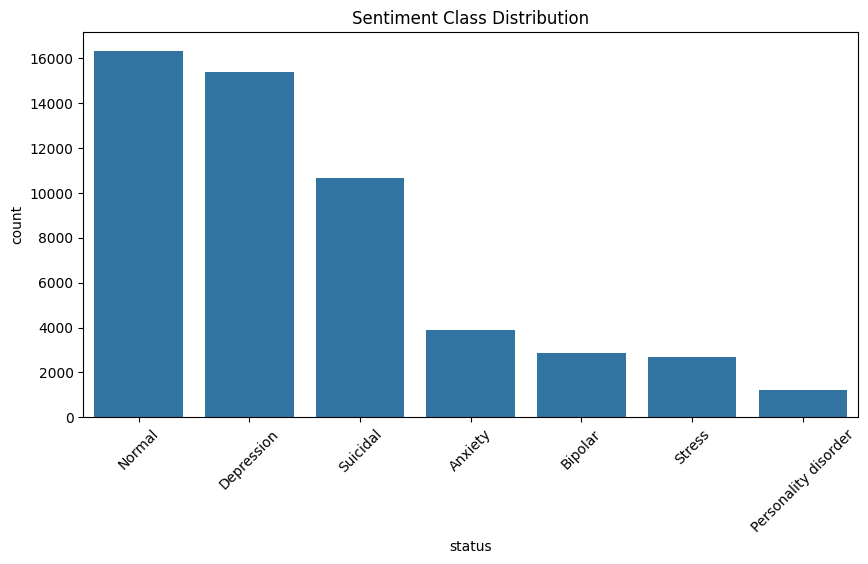


Class Percentage Distribution:
status
Normal                  30.825934
Depression              29.040590
Suicidal                20.083706
Anxiety                  7.329902
Bipolar                  5.423901
Stress                   5.031767
Personality disorder     2.264201
Name: count, dtype: float64

Average Sentence Length:
112.39328469355051

Maximum Sentence Length:
6300

Minimum Sentence Length:
1


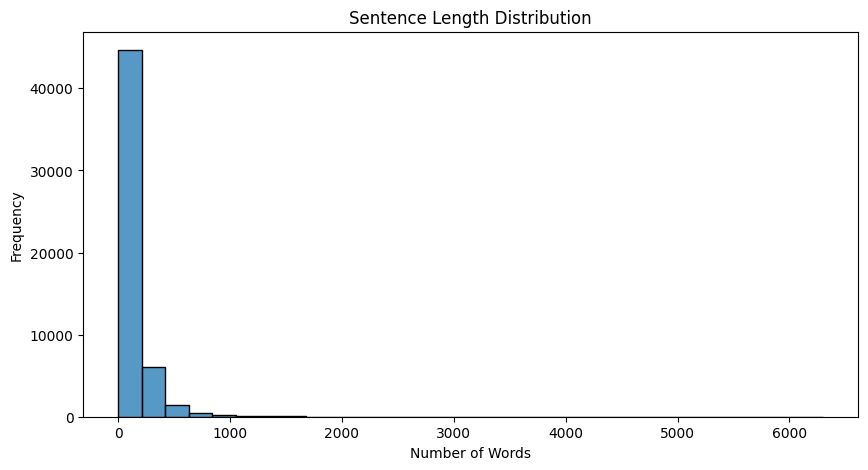

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load Dataset
# The dataset was downloaded to the path stored in the 'path' variable from kagglehub.dataset_download.
# We need to construct the full file path.

# First, let's list the contents of the path to ensure we have the correct filename
print(f"Contents of {path}: {os.listdir(path)}")

df = pd.read_csv(os.path.join(path, "Combined Data.csv"))

# First 5 rows
print(df.head())

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# -------------------------------
# 1. Number of Sentiment Classes
# -------------------------------

print("\nUnique Sentiment Classes:")
print(df['status'].unique())

print("\nClass Distribution:")
print(df['status'].value_counts())

# -------------------------------
# 2. Text Distribution
# -------------------------------

plt.figure(figsize=(10,5))
sns.countplot(x=df['status'],
              order=df['status'].value_counts().index)

plt.title("Sentiment Class Distribution")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 3. Class Imbalance Analysis
# -------------------------------

class_counts = df['status'].value_counts()

print("\nClass Percentage Distribution:")
print((class_counts / len(df)) * 100)

# -------------------------------
# 4. Average Sentence Length
# -------------------------------

df['word_count'] = df['statement'].apply(
    lambda x: len(str(x).split())
)

print("\nAverage Sentence Length:")
print(df['word_count'].mean())

print("\nMaximum Sentence Length:")
print(df['word_count'].max())

print("\nMinimum Sentence Length:")
print(df['word_count'].min())

# Sentence length visualization

plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=30)

plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

#Task 2 — Text Preprocessing
Perform:
lowercase conversion
punctuation removal
stopword removal
tokenization
padding
# vocabulary generation

In [ ]:
import pandas as pd
import re
import string
import nltk
import os

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to resolve LookupError

# Load dataset
df = pd.read_csv(os.path.join(path, "Combined Data.csv"))

# ---------------------------------------
# Text Cleaning Function
# ---------------------------------------

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Ensure text is a string to handle potential float (NaN) values
    text = str(text)

    # 1. Lowercase conversion
    text = text.lower()

    # 2. Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. Tokenization
    words = word_tokenize(text)

    # 5. Stopword removal
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Join words back
    text = " ".join(words)

    return text

# Apply preprocessing
df['clean_text'] = df['statement'].apply(clean_text)

# Display cleaned text
print(df[['statement', 'clean_text']].head())

# ---------------------------------------
# Vocabulary Generation
# ---------------------------------------

tokenizer = Tokenizer()

tokenizer.fit_on_texts(df['clean_text'])

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1

print("\nVocabulary Size:")
print(vocab_size)

# Display some vocabulary words
print("\nSample Vocabulary:")
print(list(tokenizer.word_index.items())[:20])

# ---------------------------------------
# Text to Sequences
# ---------------------------------------

sequences = tokenizer.texts_to_sequences(
    df['clean_text']
)

print("\nSample Sequence:")
print(sequences[0])

# ---------------------------------------
# Padding
# ---------------------------------------

max_length = 50

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

print("\nPadded Sequence Shape:")
print(padded_sequences.shape)

print("\nSample Padded Sequence:")
print(padded_sequences[0])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   

                                          clean_text  
0                                            oh gosh  
1  trouble sleeping confused mind restless heart ...  
2  wrong back dear forward doubt stay restless re...  
3  ive shifted focus something else im still worried  
4                im restless restless month boy mean  

Vocabulary Size:
76219

Sample Vocabulary:
[('like', 1), ('feel', 2), ('want', 3), ('’', 4), ('know', 5), ('life', 6), ('get', 7), ('even', 8), ('time', 9), ('would', 10), ('people', 11), ('really', 12), ('one', 13), ('going', 14), ('im', 15), ('think', 16), ('go', 17), ('much', 18), ('never', 19), ('day', 20)]

Sample Sequence:
[

#Task 3 — Sequence Preparation
Convert text into numerical sequences using:
Tokenizer
word indexing
padded sequences
Explain:
Why RNN cannot directly understand raw text.

In [ ]:
import pandas as pd
import os
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download NLTK resources if not already downloaded
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Load dataset
df = pd.read_csv(os.path.join(path, "Combined Data.csv"))

# ---------------------------------------
# Text Cleaning Function (duplicated from previous cell for context)
# ---------------------------------------

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Ensure text is a string to handle potential float (NaN) values
    text = str(text)

    # 1. Lowercase conversion
    text = text.lower()

    # 2. Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. Tokenization
    words = word_tokenize(text)

    # 5. Stopword removal
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Join words back
    text = " ".join(words)

    return text

# Apply preprocessing to create 'clean_text' column
df['clean_text'] = df['statement'].apply(clean_text)

# Use cleaned text column
texts = df['clean_text']

# ----------------------------------------
# 1. Tokenizer
# ----------------------------------------

tokenizer = Tokenizer()

tokenizer.fit_on_texts(texts)

# ----------------------------------------
# 2. Word Indexing
# ----------------------------------------

word_index = tokenizer.word_index

print("\nWord Index Vocabulary:")
print(list(word_index.items())[:20])

# Vocabulary size
vocab_size = len(word_index) + 1

print("\nVocabulary Size:")
print(vocab_size)

# ----------------------------------------
# 3. Text to Numerical Sequences
# ----------------------------------------

sequences = tokenizer.texts_to_sequences(texts)

print("\nSample Text:")
print(texts.iloc[0])

print("\nConverted Numerical Sequence:")
print(sequences[0])

# ----------------------------------------
# 4. Padding Sequences
# ----------------------------------------

max_length = 50

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

print("\nShape of Padded Sequences:")
print(padded_sequences.shape)

print("\nSample Padded Sequence:")
print(padded_sequences[0])
print("Length:", len(padded_sequences[0]))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



Word Index Vocabulary:
[('like', 1), ('feel', 2), ('want', 3), ('’', 4), ('know', 5), ('life', 6), ('get', 7), ('even', 8), ('time', 9), ('would', 10), ('people', 11), ('really', 12), ('one', 13), ('going', 14), ('im', 15), ('think', 16), ('go', 17), ('much', 18), ('never', 19), ('day', 20)]

Vocabulary Size:
76219

Sample Text:
oh gosh

Converted Numerical Sequence:
[479, 4567]

Shape of Padded Sequences:
(53043, 50)

Sample Padded Sequence:
[ 479 4567    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
Length: 50


#Why RNN can't directly understand the raw text?

A Recurrent Neural Network (RNN) cannot directly understand raw text because neural networks work only with numerical data, not words or sentences. Text data is made of strings and characters, but RNNs perform mathematical operations like multiplication and addition, which can only be applied to numbers. Therefore, before giving text to an RNN, the words must be converted into numerical form using techniques like tokenization and word indexing. For example, a sentence like “I feel sad” is converted into a sequence of numbers such as [4, 15, 8]. These numerical sequences are then padded to make all inputs the same length, allowing the RNN to process the text efficiently.

#Task 4 — Build Simple RNN Architecture
Students must implement:
Embedding layer
SimpleRNN layer
Dense output layer
using TensorFlow/Keras

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import numpy as np # Ensure numpy is imported for np.unique in this cell

# Build Model
model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=vocab_size, # Uses vocab_size from STRNvtHC-C4Y (76219)
        output_dim=128
        # input_length is deprecated and will be inferred from input data
    )
)

# Simple RNN Layer
model.add(
    SimpleRNN(64)
)

# Output Layer
# Uses labels from LAD4TutiBxly for the number of unique classes
model.add(
    Dense(len(np.unique(labels)), activation='softmax') # Should be 7 units
)

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#Task 5 — Model Training
Train the model using:
training dataset
validation split
GPU runtime in Google Colab
Requirements:
proper batch size
epochs
learning rate tuning


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Convert categorical labels to numerical labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(df['status'])

# Ensure labels are in the correct shape if needed (for sparse_categorical_crossentropy, 1D array is often fine)
# However, it's good practice to explicitly reshape if it's expected by Keras, though `fit_transform` usually returns 1D.
# For sparse_categorical_crossentropy, Keras usually handles 1D integer labels directly.

print("Original labels sample:", df['status'].head().tolist())
print("Encoded labels sample:", labels[:5].tolist())
print("Unique encoded labels:", np.unique(labels))
print("Number of unique classes:", len(np.unique(labels)))

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    labels,
    test_size=0.2,
    random_state=42
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)


Original labels sample: ['Anxiety', 'Anxiety', 'Anxiety', 'Anxiety', 'Anxiety']
Encoded labels sample: [0, 0, 0, 0, 0]
Unique encoded labels: [0 1 2 3 4 5 6]
Number of unique classes: 7
Epoch 1/10
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4547 - loss: 1.4674 - val_accuracy: 0.3499 - val_loss: 1.4719
Epoch 2/10
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5155 - loss: 1.3094 - val_accuracy: 0.5355 - val_loss: 1.2138
Epoch 3/10
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5983 - loss: 1.0444 - val_accuracy: 0.5711 - val_loss: 1.0200
Epoch 4/10
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6758 - loss: 0.8280 - val_accuracy: 0.5667 - val_loss: 1.1462
Epoch 5/10
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7238 - loss: 0.6885 - val_accuracy: 0.5971 - val_loss: 1.0422
Epoch 6/10
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.7735 - loss: 0.5782 - val_accuracy: 0.5731 - val_loss: 1.1817
Epoch 7/10
1061/1061 ━━━━━━━━━━━━

#Task 6 — Model Evaluation
Evaluate using:
Accuracy
Precision
Recall
F1 Score
Confusion Matrix

332/332 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.22923932510132905
Precision: 0.3243822041993063
Recall: 0.22923932510132905
F1 Score: 0.22162879163992202

Classification Report:
              precision    recall  f1-score   support

           0       0.09      0.15      0.12       779
           1       0.04      0.19      0.07       580
           2       0.44      0.07      0.11      3100
           3       0.43      0.53      0.47      3327
           4       0.03      0.12      0.05       248
           5       0.06      0.06      0.06       557
           6       0.26      0.08      0.12      2018

    accuracy                           0.23     10609
   macro avg       0.19      0.17      0.14     10609
weighted avg       0.32      0.23      0.22     10609



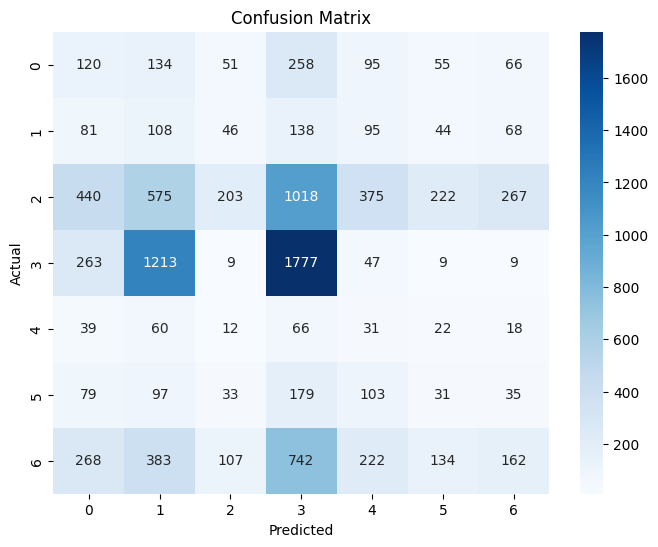

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)

# Convert probabilities to class labels
y_pred_classes = y_pred.argmax(axis=1)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(
    y_test,
    y_pred_classes,
    average='weighted'
)
print("Precision:", precision)

# Recall
recall = recall_score(
    y_test,
    y_pred_classes,
    average='weighted'
)
print("Recall:", recall)

# F1 Score
f1 = f1_score(
    y_test,
    y_pred_classes,
    average='weighted'
)
print("F1 Score:", f1)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_classes
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot Confusion Matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Task 7 — Sequence Understanding
You must explain:
how RNN remembers previous words
hidden state concept
sequential learning behavior


A Recurrent Neural Network (RNN) is designed to work with sequential data such as text, where the order of words is important. Unlike traditional neural networks, an RNN processes one word at a time and remembers information from previous words while reading the sentence. This helps the model understand the context and meaning of the text more effectively. For example, in the sentence “I am not happy,” the word “not” changes the meaning of “happy,” and the RNN can understand this because it remembers the earlier words.

The memory mechanism of an RNN is called the hidden state. The hidden state stores information learned from previous words and passes it to the next step while processing the sequence. Each time a new word is read, the hidden state is updated with both the current input and the previous memory. In this way, the RNN continuously carries contextual information throughout the sentence.

This process is known as sequential learning behavior because the network learns patterns based on the sequence and relationship between words. The prediction at any point depends not only on the current word but also on the words that appeared before it. Due to this ability to remember previous information, RNNs are widely used in applications such as sentiment analysis, text prediction, language translation, and speech recognition.

#Task 8 — Real-Time Prediction
Test the model using:
custom user sentences
emotional text examples
unseen sentences

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Example labels
labels = ['sadness', 'joy', 'anger', 'fear', 'love', 'surprise']

def predict_sentiment(text):

    # Convert text into sequence
    sequence = tokenizer.texts_to_sequences([text])

    # Padding
    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post'
    )

    # Prediction
    prediction = model.predict(padded)

    # Highest probability class
    predicted_class = np.argmax(prediction)

    # Confidence score
    confidence = np.max(prediction)

    print("Input Sentence:", text)
    print("Predicted Emotion:", labels[predicted_class])
    print("Confidence Score:", confidence)

# Test Sentences
predict_sentiment("I feel very happy today")

predict_sentiment("I am completely exhausted and depressed")

predict_sentiment("Nobody understands me anymore")

predict_sentiment("I am excited about my future")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
Input Sentence: I feel very happy today
Predicted Emotion: fear
Confidence Score: 0.19125979
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Input Sentence: I am completely exhausted and depressed
Predicted Emotion: fear
Confidence Score: 0.19652131
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Input Sentence: Nobody understands me anymore
Predicted Emotion: joy
Confidence Score: 0.1888421
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Input Sentence: I am excited about my future
Predicted Emotion: sadness
Confidence Score: 0.18630074


#Task 9 — Save the Trained Model
Export:
trained RNN model
tokenizer
label encoder

In [ ]:
import pickle

# Save Trained Model
model.save("mental_health_rnn_model.h5")

print("Model saved successfully")

# Save Tokenizer
with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully")

# Save Label Encoder
with open("label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

print("Label Encoder saved successfully")

Model saved successfully
Tokenizer saved successfully
Label Encoder saved successfully
